In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import yfinance as yf

from dotenv import load_dotenv
import os
import sys

import sqlite3

load_dotenv()  # carga .env
sys.path.insert(0, os.path.join(os.environ["CUANTIS_ROOT"], "src"))

In [2]:
from cuantis_utils.AssetBehaveSimulation import AssetBehaveSimulation

In [3]:
ticket = ["MELI"]
start_date = "2022-01-01"
end_date = "2026-03-03"

simulation = AssetBehaveSimulation(tickets=ticket, start_date=start_date, end_date=end_date, num_distributions=70)

In [4]:
n_prices = len(simulation.prices)

result = simulation.back_simulation(simulations=n_prices, steps=n_prices)
result

array([[1332.93994141, 1333.88155562, 1334.62606606, ..., 1835.08832173,
        1840.13753544, 1838.99108136],
       [1332.93994141, 1333.46322317, 1334.81392899, ..., 1808.73514101,
        1808.22251353, 1809.37255542],
       [1332.93994141, 1333.39098343, 1333.93643817, ..., 1731.85900363,
        1733.71269499, 1736.62145226],
       ...,
       [1332.93994141, 1334.16256426, 1333.79120035, ..., 1750.71565223,
        1746.8548499 , 1747.45852638],
       [1332.93994141, 1332.39708814, 1332.74888699, ..., 1752.12506067,
        1752.43819578, 1752.75234842],
       [1332.93994141, 1336.0161742 , 1336.5938894 , ..., 1840.19320048,
        1838.1482651 , 1838.76877531]], shape=(1043, 1043))

In [5]:
simulation.distributions_name

'johnsonsu'

In [17]:
simulation.distributions_params

(0.013446876643257144,
 1.2072246812916025,
 0.0011954873254323578,
 0.027100166407986532)

In [6]:
result[0]

array([1332.93994141, 1333.88155562, 1334.62606606, ..., 1835.08832173,
       1840.13753544, 1838.99108136], shape=(1043,))

In [7]:
len(result[0])

1043

In [9]:
len(simulation.prices["MELI"].index)

1043

In [11]:
df_simulation = pd.DataFrame(result.T, index=simulation.prices["MELI"].index)
df_simulation

,0,1,2,3,4,5,6,7,8,9,...,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,...,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941
2022-01-04,1333.881556,1333.463223,1333.390983,1333.430742,1336.680500,1333.244500,1334.658606,1329.943344,1334.199178,1333.640558,...,1333.992650,1333.677895,1330.643862,1334.099513,1334.267986,1333.062922,1333.483043,1334.162564,1332.397088,1336.016174
2022-01-05,1334.626066,1334.813929,1333.936438,1333.606649,1337.231704,1333.871309,1335.762161,1329.189403,1334.259604,1332.378779,...,1332.568033,1334.106840,1331.822580,1334.284514,1334.520566,1333.374862,1333.983873,1333.791200,1332.748887,1336.593889
2022-01-06,1332.110470,1332.726363,1333.817423,1333.276634,1337.655169,1334.193354,1335.319568,1329.637394,1334.117683,1334.421140,...,1333.391488,1334.285096,1332.387251,1336.294570,1333.655227,1332.067074,1336.515345,1333.232374,1334.097399,1335.662146
2022-01-07,1333.565998,1332.793541,1334.842082,1332.759009,1337.878917,1334.192810,1333.238889,1327.764402,1332.934995,1334.997552,...,1335.742315,1334.176101,1331.134842,1339.761063,1334.224270,1331.175212,1336.728218,1334.735675,1332.505630,1335.985589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,1833.447960,1807.190637,1731.342348,1764.912594,1892.873969,1805.756453,1882.379420,1800.848780,1886.791235,1889.216366,...,1814.307627,1844.125306,1781.084180,1887.726305,1892.796701,1702.311538,1891.857665,1751.101703,1749.357827,1838.175244
2026-02-25,1833.841957,1808.171890,1730.631400,1766.645446,1892.771602,1806.008499,1882.423886,1801.738324,1887.053765,1887.782825,...,1815.352188,1846.906833,1782.466470,1888.856046,1891.562333,1702.888874,1892.572448,1752.556722,1750.531969,1839.006554
2026-02-26,1835.088322,1808.735141,1731.859004,1767.500342,1891.463606,1806.273816,1883.107865,1802.280252,1886.421546,1888.466183,...,1814.334785,1847.313609,1783.809647,1889.622330,1892.409960,1706.782090,1892.355420,1750.715652,1752.125061,1840.193200


In [12]:
df_plot = pd.concat([simulation.prices, df_simulation], axis = 1)
df_plot

,MELI,0,1,2,3,4,5,6,7,8,...,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,...,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941,1332.939941
2022-01-04,1241.380005,1333.881556,1333.463223,1333.390983,1333.430742,1336.680500,1333.244500,1334.658606,1329.943344,1334.199178,...,1333.992650,1333.677895,1330.643862,1334.099513,1334.267986,1333.062922,1333.483043,1334.162564,1332.397088,1336.016174
2022-01-05,1129.689941,1334.626066,1334.813929,1333.936438,1333.606649,1337.231704,1333.871309,1335.762161,1329.189403,1334.259604,...,1332.568033,1334.106840,1331.822580,1334.284514,1334.520566,1333.374862,1333.983873,1333.791200,1332.748887,1336.593889
2022-01-06,1156.780029,1332.110470,1332.726363,1333.817423,1333.276634,1337.655169,1334.193354,1335.319568,1329.637394,1334.117683,...,1333.391488,1334.285096,1332.387251,1336.294570,1333.655227,1332.067074,1336.515345,1333.232374,1334.097399,1335.662146
2022-01-07,1085.359985,1333.565998,1332.793541,1334.842082,1332.759009,1337.878917,1334.192810,1333.238889,1327.764402,1332.934995,...,1335.742315,1334.176101,1331.134842,1339.761063,1334.224270,1331.175212,1336.728218,1334.735675,1332.505630,1335.985589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,1922.560059,1833.447960,1807.190637,1731.342348,1764.912594,1892.873969,1805.756453,1882.379420,1800.848780,1886.791235,...,1814.307627,1844.125306,1781.084180,1887.726305,1892.796701,1702.311538,1891.857665,1751.101703,1749.357827,1838.175244
2026-02-25,1767.709961,1833.841957,1808.171890,1730.631400,1766.645446,1892.771602,1806.008499,1882.423886,1801.738324,1887.053765,...,1815.352188,1846.906833,1782.466470,1888.856046,1891.562333,1702.888874,1892.572448,1752.556722,1750.531969,1839.006554
2026-02-26,1740.880005,1835.088322,1808.735141,1731.859004,1767.500342,1891.463606,1806.273816,1883.107865,1802.280252,1886.421546,...,1814.334785,1847.313609,1783.809647,1889.622330,1892.409960,1706.782090,1892.355420,1750.715652,1752.125061,1840.193200


<Axes: xlabel='Date'>

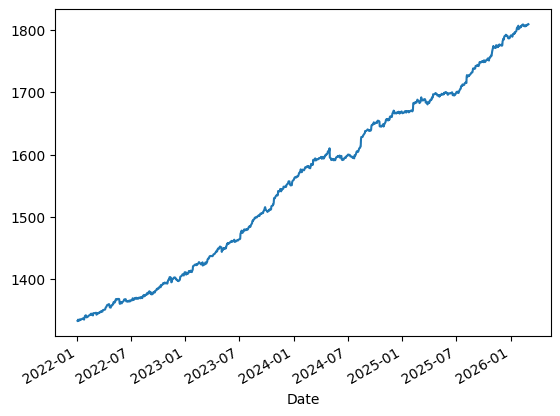

In [13]:
df_plot[1].plot()

In [14]:
filtro = df_plot.index >= "2022-01-01"
filtro

array([ True,  True,  True, ...,  True,  True,  True], shape=(1043,))

<Figure size 640x480 with 0 Axes>

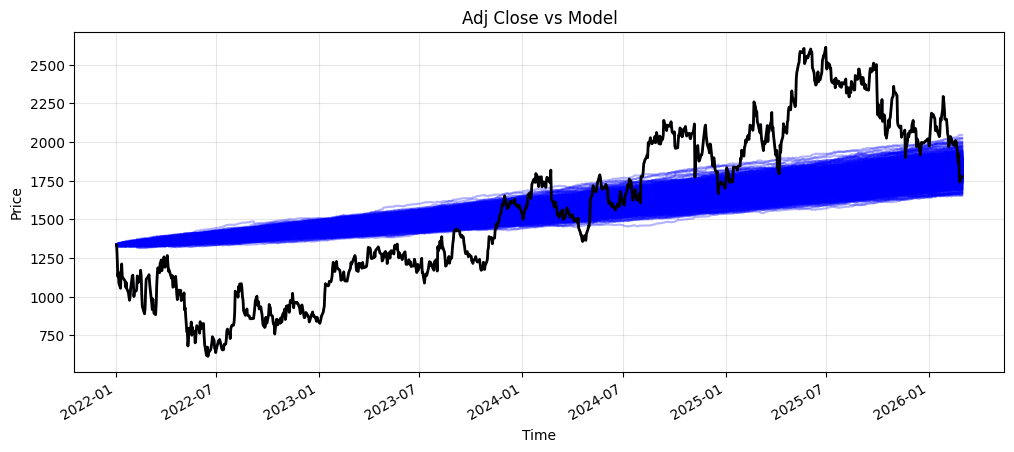

In [16]:
plt.figure()

ax = df_plot[filtro].plot(figsize=(12,5), title="Adj Close vs Model", legend=False, alpha=0.3, color="blue")
df_plot[filtro]["MELI"].plot(ax = ax, color = "black", lw = 2, label = "CVX")

ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
plt.show()